# Feature importance & selection

Today we'll talk about:
1. Feature importances and how to calculate them
2. Feature selection - how to choose which features to remove from a model
3. Model explainability - which algorithms are more opaque than others


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import urllib

pd.set_option('display.max_columns', None)

# Suppress all warnings
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Helper function for plotting
def plot_importances(importances, features, xlabel="importance"):
    df = pd.DataFrame({
        'feature': features,
        'importance': importances
    })
    df = df.sort_values('importance', ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=df)
    plt.xlabel(xlabel)


## The data

In [3]:
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/income.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    df = pd.read_csv(response)

In [4]:
# income column is already 0/1 and columns are already clean
df.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,1,2174.0,0.0,40.0,United-States,0
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,1,0.0,0.0,13.0,United-States,0
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,1,0.0,0.0,40.0,United-States,0
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0.0,0.0,40.0,United-States,0
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,0,0.0,0.0,40.0,Cuba,0


In [5]:
numerical_features = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
]


In [6]:
from sklearn.model_selection import train_test_split

X = df[numerical_features]
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Feature importance

Not every predictor we use in a model is equal - some have a lot of signal and contribute a lot to the prediction accuracy, and some barely matter or don't matter at all. More features means a more complex model, and additional complexity always has to be justified. Therefore, if we have features in a model that do not contribute to the model's accuracy, we'd rather remove the features.

### Logistic regression coefficients


A good first example is logistic regression. In logistic regression, the coefficient of a feature is the closest thing we have to a built-in feature importance. Larger absolute coefficients usually mean a stronger effect on the prediction.

However, there is a problem: coefficients can only be compared directly when features are on the same scale.


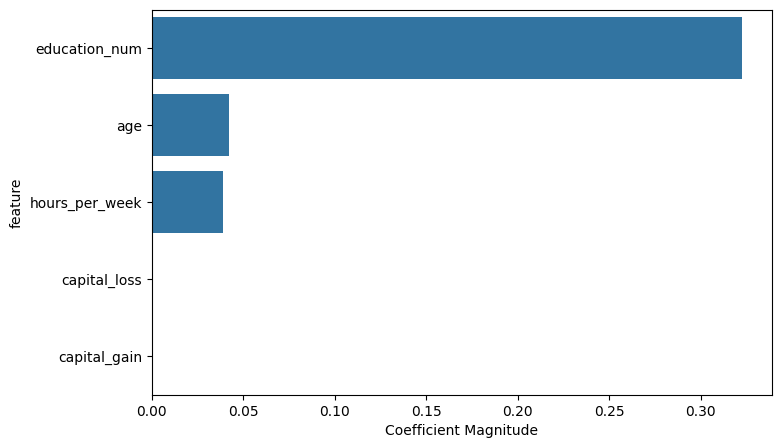

In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, penalty=None)
lr_model.fit(X_train, y_train)

plot_importances(
    np.abs(lr_model.coef_[0]), X_train.columns, xlabel="Coefficient Magnitude"
)


At first glance, `education_num` looks much more important than `capital_gain` or `capital_loss`. But this comparison is misleading because the features have very different ranges.

A logistic regression coefficient tells us what happens when a feature increases by one unit. A one-unit increase in `education_num` is not comparable to a one-unit increase in `capital_gain`, because those features live on very different scales.

In [8]:
X_train.agg(["min", "max", "std"]).round(1)


,age,education_num,capital_gain,capital_loss,hours_per_week
min,17.0,1.0,0.0,0.0,1.0
max,90.0,16.0,99999.0,4356.0,99.0
std,13.7,2.6,7500.0,402.8,12.4


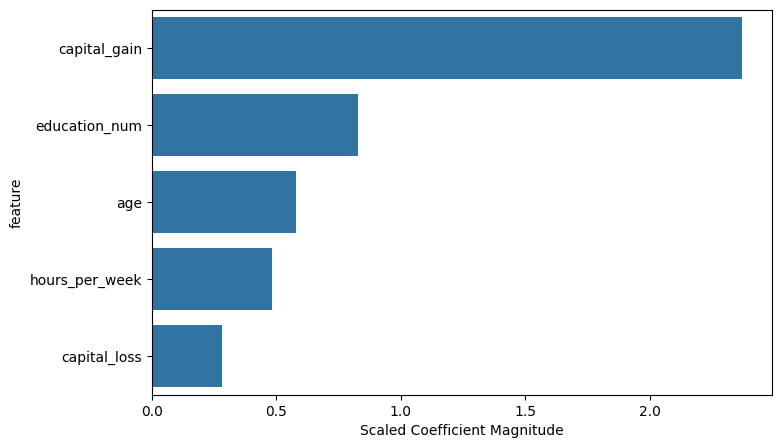

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_model_scaled = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000)),
    ]
)
lr_model_scaled.fit(X_train, y_train)

plot_importances(
    np.abs(lr_model_scaled.named_steps["logreg"].coef_[0]),
    X_train.columns,
    xlabel="Scaled Coefficient Magnitude",
)

After scaling, the ranking changes.


### Mean decrease in Gini impurity/MSE

Tree-based models give us another kind of feature importance, and they can be calculated out of the box.


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=50, max_depth=10, min_samples_split=10
)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="roc_auc")
print(f"Mean ROC AUC: {cv_scores.mean():.4f}")

rf_model.fit(X_train, y_train)

Mean ROC AUC: 0.8630


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
rf_model.feature_importances_

array([0.20025959, 0.23114877, 0.34121044, 0.12006591, 0.10731529])

How were these feature importances calculated and what do they mean?

Every split in a tree separates the data into two more homogeneous groups - it reduces Gini impurity for classification, or MSE for regression. A feature's importance is the total reduction its splits contribute across the whole forest.

Features that get picked often and produce big drops in impurity score high in terms of importance. These feature importances are computed during training.

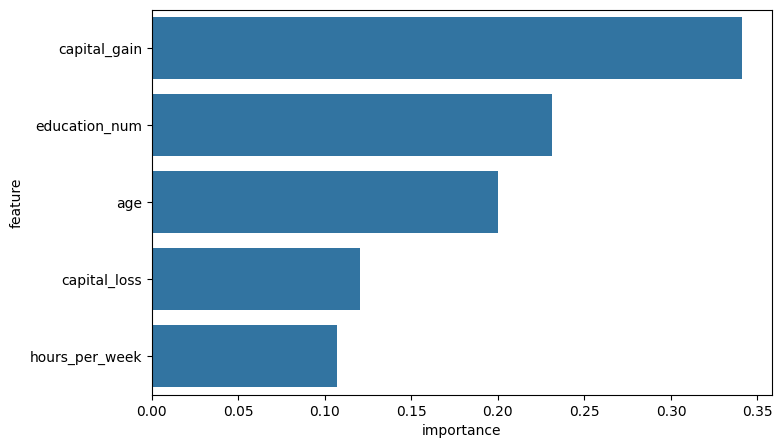

In [12]:
plot_importances(rf_model.feature_importances_, X_train.columns)


It seems that of all features that we used in the model, `capital_loss` and `hours_per_week` are the least important ones. So what happens if we remove those features from the model?


In [13]:
cv_scores_reduced = cross_val_score(
    rf_model,
    X_train.drop(["capital_loss", "hours_per_week"], axis=1),
    y_train,
    cv=5,
    scoring="roc_auc",
)

print(f"original: {cv_scores.mean():.4f}")
print(f"without capital_loss and hours_per_week: {cv_scores_reduced.mean():.4f}")

original: 0.8630
without capital_loss and hours_per_week: 0.8408


We can also check the impact to model's performance from removing the most important feature.


In [14]:
cv_scores_reduced2 = cross_val_score(
    rf_model,
    X_train.drop(["capital_gain"], axis=1),
    y_train,
    cv=5,
    scoring="roc_auc",
)

print(f"original: {cv_scores.mean():.4f}")
print(f"without capital_gain: {cv_scores_reduced2.mean():.4f}")

original: 0.8630
without capital_gain: 0.8316


### Permutation importance

Permutation importance measures how much a feature contributes to the model by shuffling it and measuring how much the model's performance drops. For this to be meaningful we need to evaluate on a held-out set - if we permuted a feature in the training data, the score drop would mostly reflect how well the model memorized that feature rather than its real predictive power. So before running permutation importance we split off a validation set from `X_train` and refit the model on the remaining data.

1. Measure the model's baseline performance on the validation set.
2. Shuffle one feature in the validation set.
3. Measure the performance again.
4. The bigger the drop in performance, the more important that feature is.

The cell below implements the algorithm.

Baseline validation ROC AUC: 0.8620


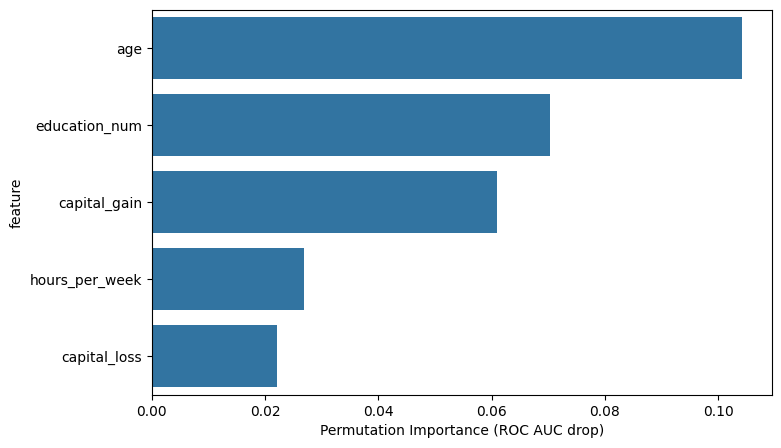

In [15]:
from sklearn.metrics import roc_auc_score

# Split off a validation set and refit the model
X_train_tmp, X_val, y_train_tmp, y_val = train_test_split(X_train, y_train, test_size=0.25)
rf_model.fit(X_train_tmp, y_train_tmp)

baseline_score = roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1])

permutation_importances = []

for feature in X_val.columns:
    drops = []

    for _ in range(10):
        X_val_permuted = X_val.copy()

        # Shuffle one feature and assign it back
        shuffled_values = X_val_permuted[feature].to_numpy().copy()
        np.random.shuffle(shuffled_values)
        X_val_permuted[feature] = shuffled_values

        # Make predictions
        permuted_preds = rf_model.predict_proba(X_val_permuted)[:, 1]

        # Calculate new score
        permuted_score = roc_auc_score(y_val, permuted_preds)
        drops.append(baseline_score - permuted_score)

    permutation_importances.append(np.mean(drops))

print(f"Baseline validation ROC AUC: {baseline_score:.4f}")
plot_importances(
    permutation_importances,
    X_val.columns,
    xlabel="Permutation Importance (ROC AUC drop)",
)

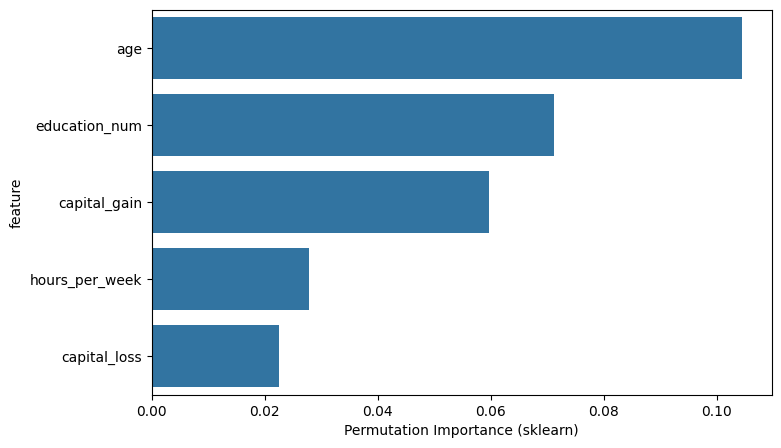

In [16]:
from sklearn.inspection import permutation_importance

importances = permutation_importance(
    rf_model,
    X_val,
    y_val,
    n_repeats=10,
    scoring="roc_auc",
)

plot_importances(
    importances.importances_mean,
    X_val.columns,
    xlabel="Permutation Importance (sklearn)",
)


Permutation importance has two main advantages:
- it is model-agnostic, so it works with any fitted model;
- it is easy to understand, because it measures how much model performance drops when a feature is shuffled.

Its main disadvantages are:
- it evaluates features one at a time, so it may miss or understate importance that comes from interactions between features;
- if two features contain similar information, each one can look less important than it really is, because the model can fall back on the other.


## Feature selection

Feature selection means choosing a subset of predictors instead of using every available feature. We do this to make models simpler and easier to interpret, reduce the cost of collecting and maintaining features, and sometimes improve performance by removing noisy or redundant variables.

### Feature correlations

A useful first step in feature selection is to look at correlations between features. If two features are highly correlated, they carry essentially the same information and the model is unlikely to benefit from both.

Text(0.5, 1.0, 'Feature Correlation Matrix')

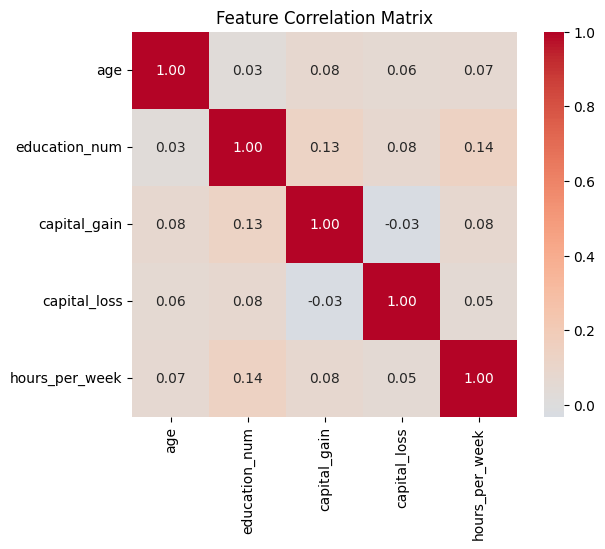

In [17]:
corr = X_train.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")


### Sequential selection

Sequential selection adds or removes features one at a time, always choosing the move that helps cross-validated performance the most.

- **Forward selection**: start with no features; at each step add the single feature that improves CV performance the most. Stop when you have the target number of features, or when no addition helps anymore.
- **Backward selection**: start with all features; at each step remove the feature whose removal hurts CV performance the least. Stop at the target number, or when any removal would hurt too much.

In sklearn, you pass either a fixed `n_features_to_select`, or use `n_features_to_select="auto"` with a `tol` threshold to let the selector stop automatically.

In [18]:
from sklearn.feature_selection import SequentialFeatureSelector

backward_selector = SequentialFeatureSelector(
    lr_model_scaled,
    direction="backward",
    # n_features_to_select=3,
    # Alternatively
    n_features_to_select="auto",
    tol=-0.02,  # stop once removing a feature would drop ROC AUC by more than 0.005
    scoring="roc_auc",
    cv=5,
)

backward_selector.fit(X_train, y_train)

selected_features = X_train.columns[backward_selector.get_support()].tolist()
print("selected features:", selected_features)

cv_scores_full = cross_val_score(
    lr_model_scaled, X_train, y_train, cv=5, scoring="roc_auc")
cv_scores_selected = cross_val_score(
    lr_model_scaled,
    X_train[selected_features],
    y_train,
    cv=5,
    scoring="roc_auc",
)

print(f"all features: {cv_scores_full.mean():.4f}")
print(f"selected features: {cv_scores_selected.mean():.4f}")


selected features: ['age', 'education_num', 'capital_gain']
all features: 0.8287
selected features: 0.8020


## Model explainability

In logistic or linear regression, we can explain the models via coefficients - a coefficient basically says what impact a one-unit increase in the predictor has on the prediction value (log-odds in case of logistic regression). Decision trees are likewise quite transparent, since we can explain the value of a single prediction by going down the tree. However, the same cannot be said about ensemble methods, such as random forests that combine many different decision trees.

Having explainable models is important in sensitive domains such as medicine and banking, since there we not only care about having accurate decisions, but we also care about being able to explain why the model made a specific decision - models have to be auditable. However, there is a trade-off here - more interpretable models tend to be less accurate on complex problems than random forests or neural networks.

We call non-interpretable models black-box models - they are black boxes that receive data and output a prediction, but it's difficult to understand what's going on inside the algorithm. We also refer to interpretable models as glass-box models. Model-agnostic feature importances can be helpful here, but e.g. permutation importance is a *global* interpretability method and will not help us understand why a single prediction was made.


![Model Explainability](explainability.png)


### Partial dependence plots

Permutation importance tells us how much a feature matters, but not how it affects the prediction. A partial dependence plot (PDP) shows how the model's average prediction changes as we vary a single feature.

1. Pick a feature and create a range of values for it.
2. Loop through the feature values in the list and for each value:
    1. Overwrite that feature in the dataset with this value, leaving every other feature untouched.
    2. Predict on the modified dataset.
    3. Save the average of the predictions.
3. Plot the mean predictions against the values.

Effectively we're asking: if everyone had age = X (e.g. 25) but kept everything else, what would the average prediction be?


Text(0, 0.5, 'Mean predicted probability')

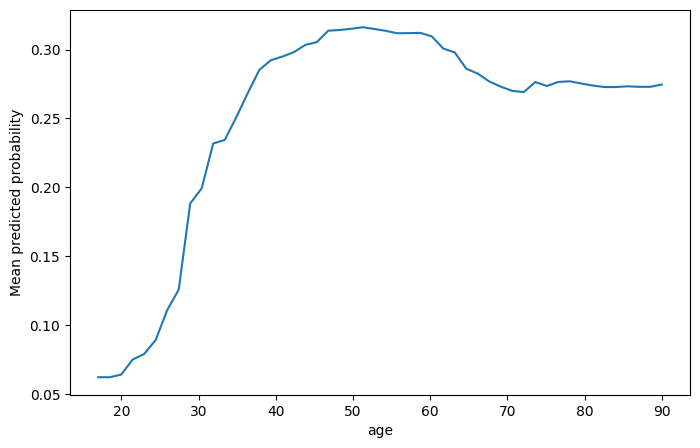

In [19]:
feature = "age"
values = np.linspace(X_train[feature].min(), X_train[feature].max(), 50)

pdp_values = []
for value in values:
    X_modified = X_train.copy()

    # Insert the value for the feature
    X_modified[feature] = value

    # Make predictions and store the mean
    preds = rf_model.predict_proba(X_modified)[:, 1]
    pdp_values.append(preds.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(values, pdp_values)
plt.xlabel(feature)
plt.ylabel("Mean predicted probability")


Text(0, 0.5, 'Partial dependence')

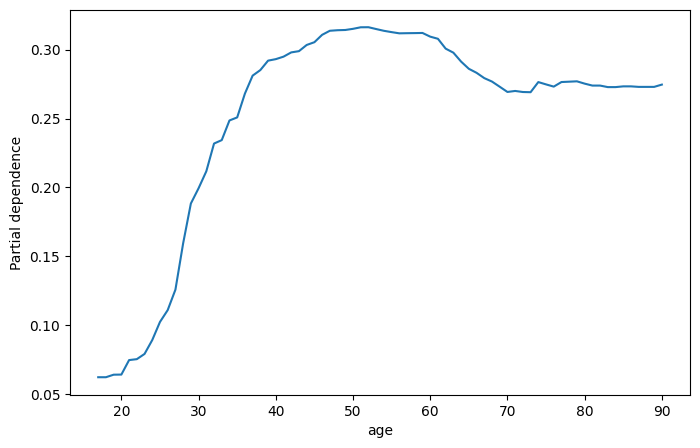

In [20]:
from sklearn.inspection import partial_dependence

feature = "age"
result = partial_dependence(rf_model, X_train, features=[feature])

plt.figure(figsize=(8, 5))
plt.plot(result["grid_values"][0], result["average"][0])
plt.xlabel(feature)
plt.ylabel("Partial dependence")


## Tasks


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["race", "relationship", "marital_status"]
all_features = numerical_features + categorical_features

X = df[all_features]
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
    ]
)

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=10,
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Let's show the top 15 features by feature importance

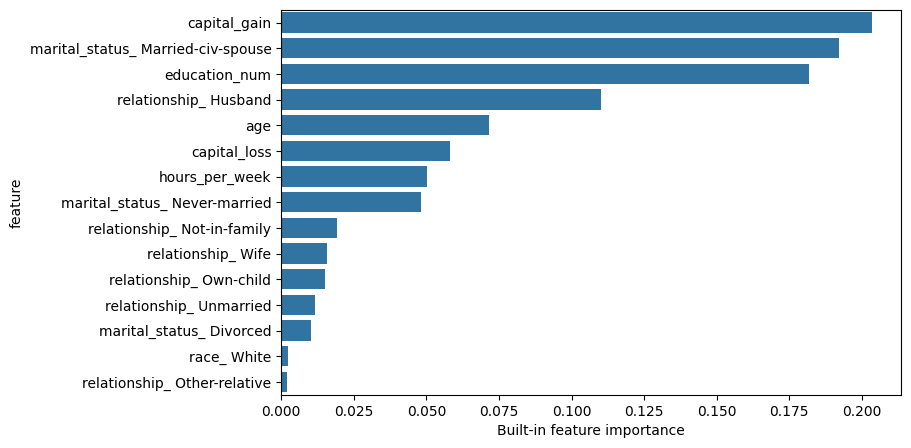

In [23]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
built_in_importances = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_pipeline.named_steps["rf"].feature_importances_,
    }
).sort_values("importance", ascending=False)

built_in_importances["feature"] = built_in_importances["feature"].str.replace(
    "cat__", "", regex=False
)
built_in_importances["feature"] = built_in_importances["feature"].str.replace(
    "num__", "", regex=False
)

top_15_importances = built_in_importances.head(15)

plot_importances(
    top_15_importances["importance"],
    top_15_importances["feature"],
    xlabel="Built-in feature importance",
)



### Task 1

Permutation importance needs a held-out set so the score drops reflect real predictive power rather than memorization. Split off a validation set from `X_train`, refit the model on the remaining data, and compute permutation feature importances on the validation set. Compare them with the built-in importances shown above.

### Task 2

Show partial dependence plots for important features and explain what they suggest about how the model makes predictions.

## Recap

- **Feature importance** quantifies how much each feature contributes to a model's predictions.
    - For logistic regression - coefficients of scaled features.
    - For random forests - mean Gini impurity / MSE decrease.
    - For any method - permutation importance.

- **Feature selection** picks a subset of predictors for simpler models.
    - Correlation analysis - keep only one feature among a set of correlated features.
    - Sequential (forward/backward) selection
- **Model explainability** is about understanding *why* a model makes a given prediction. Linear models and single trees are glass-box; random forests and neural nets are black-box. Partial dependence plots let us peek inside a black-box model by showing how its average prediction depends on one feature.

## Next week

We'll move into **unsupervised learning** - problems where there's no target variable to predict. We'll cover:

- **k-means clustering** - grouping similar observations together.
- **PCA** - reducing the dimensionality of the data while keeping as much variance as possible.
